# Python Notebook 3
## Ensemble Classifier and Regression Decision Trees

**Student Name:** Sanidu Harsha  
**Module:** 5DATA002W.2 Machine Learning & Data Mining  
**Case Study A:** Loan Approval Status Ensemble Classification  
**Case Study B:** Maximum Loan Amount Regression Decision Trees

This notebook contains:
- A probability-based voting ensemble classifier using TWO base learners
- A fully grown Decision Tree Regressor
- A pruned Decision Tree Regressor with maximum depth = 4
- Evaluation and visualisation of all required models

In [1]:
# Import core libraries for data handling.
import pandas as pd
import numpy as np

# Import plotting libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Import data splitting and preprocessing tools.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import classification models.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

# Import regression models.
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Import evaluation metrics for classification.
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Import evaluation metrics for regression.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Show plots inside the notebook.
%matplotlib inline

### Upload the cleaned datasets from Notebook 1
Upload both:
- classification_dataset_cleaned.csv
- regression_dataset_cleaned.csv

In [3]:
# Import the upload helper for Google Colab.
from google.colab import files

# Upload the cleaned datasets.
uploaded = files.upload()

Saving classification_dataset_cleaned.csv to classification_dataset_cleaned.csv
Saving regression_dataset_cleaned.csv to regression_dataset_cleaned.csv


In [2]:
# Read the cleaned classification dataset.
classification_df = pd.read_csv("classification_dataset_cleaned.csv")

# Read the cleaned regression dataset.
regression_df = pd.read_csv("regression_dataset_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'classification_dataset_cleaned.csv'

### Check the loaded datasets

In [ ]:
# Display the first five rows of the classification dataset.
classification_df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,0,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,35000,False,False,False,False,True,False,False,False,False


In [ ]:
# Display the first five rows of the regression dataset.
regression_df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,35000,False,False,False,False,True,False,False,False,False


In [ ]:
# Display the shape of the classification dataset.
print("Classification dataset shape:", classification_df.shape)

# Display the shape of the regression dataset.
print("Regression dataset shape:", regression_df.shape)

Classification dataset shape: (58645, 18)
Regression dataset shape: (50295, 17)


## Part A: Ensemble Classifier for Loan Approval Status
This section builds a probability-based soft voting ensemble classifier using TWO base learners.

In [ ]:
# Remove leakage columns for classification
cols_to_drop = ["loan_approval_status", "max_allowed_loan"]

if "credit_application_acceptance" in classification_df.columns:
    cols_to_drop.append("credit_application_acceptance")

X_cls = classification_df.drop(cols_to_drop, axis=1)
y_cls = classification_df["loan_approval_status"]

# Display feature names
print(X_cls.columns.tolist())

['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'payment_default_on_file_Y']


In [ ]:
# Split the classification data into training and testing sets.
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

# Display the classification split shapes.
print("X_cls_train shape:", X_cls_train.shape)
print("X_cls_test shape:", X_cls_test.shape)
print("y_cls_train shape:", y_cls_train.shape)
print("y_cls_test shape:", y_cls_test.shape)

X_cls_train shape: (46916, 16)
X_cls_test shape: (11729, 16)
y_cls_train shape: (46916,)
y_cls_test shape: (11729,)


### Define the two base learners
This notebook uses:
- Logistic Regression
- K-Nearest Neighbour

In [ ]:
# Create a pipeline for Logistic Regression with feature scaling.
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Create a pipeline for KNN with feature scaling.
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
# Fit the Logistic Regression pipeline on the training data.
lr_pipeline.fit(X_cls_train, y_cls_train)

# Fit the KNN pipeline on the training data.
knn_pipeline.fit(X_cls_train, y_cls_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

### Evaluate the two base learners before combining them

In [ ]:
# Generate predictions for the Logistic Regression base learner.
lr_base_pred = lr_pipeline.predict(X_cls_test)

# Generate probability scores for the Logistic Regression base learner.
lr_base_prob = lr_pipeline.predict_proba(X_cls_test)[:, 1]

In [ ]:
# Generate predictions for the KNN base learner.
knn_base_pred = knn_pipeline.predict(X_cls_test)

# Generate probability scores for the KNN base learner.
knn_base_prob = knn_pipeline.predict_proba(X_cls_test)[:, 1]

In [ ]:
# Display the confusion matrix for Logistic Regression.
lr_base_cm = confusion_matrix(y_cls_test, lr_base_pred)
print("Logistic Regression Base Learner Confusion Matrix:")
print(lr_base_cm)

Logistic Regression Base Learner Confusion Matrix:
[[9796  263]
 [ 958  712]]


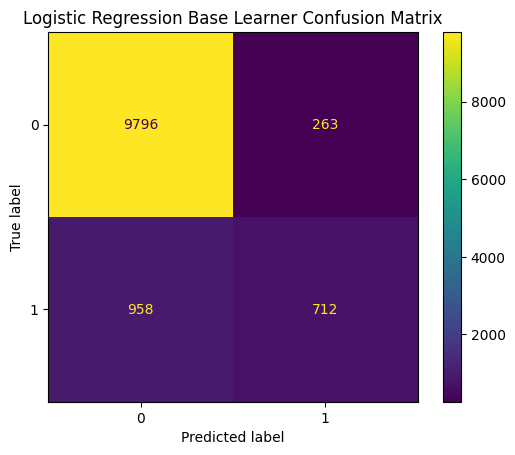

In [ ]:
# Plot the confusion matrix for Logistic Regression.
disp = ConfusionMatrixDisplay(confusion_matrix=lr_base_cm)
disp.plot()
plt.title("Logistic Regression Base Learner Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for Logistic Regression.
print("Logistic Regression Base Learner Classification Report:")
print(classification_report(y_cls_test, lr_base_pred))

Logistic Regression Base Learner Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729



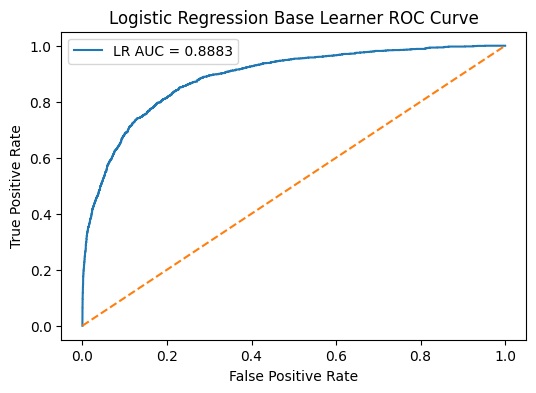

In [ ]:
# Compute and plot the ROC curve for Logistic Regression.
lr_base_fpr, lr_base_tpr, _ = roc_curve(y_cls_test, lr_base_prob)
lr_base_auc = roc_auc_score(y_cls_test, lr_base_prob)

plt.figure(figsize=(6, 4))
plt.plot(lr_base_fpr, lr_base_tpr, label=f"LR AUC = {lr_base_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression Base Learner ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Display the confusion matrix for KNN.
knn_base_cm = confusion_matrix(y_cls_test, knn_base_pred)
print("KNN Base Learner Confusion Matrix:")
print(knn_base_cm)

KNN Base Learner Confusion Matrix:
[[9851  208]
 [ 745  925]]


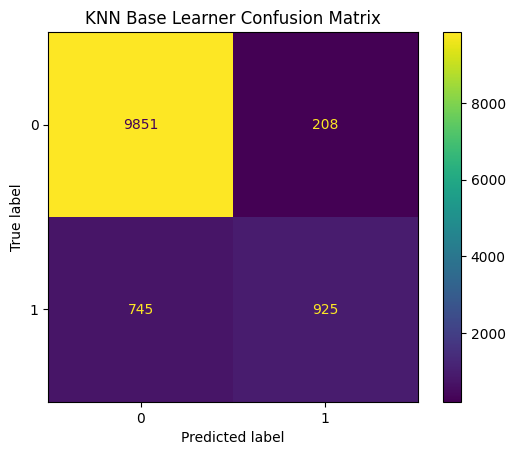

In [ ]:
# Plot the confusion matrix for KNN.
disp = ConfusionMatrixDisplay(confusion_matrix=knn_base_cm)
disp.plot()
plt.title("KNN Base Learner Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for KNN.
print("KNN Base Learner Classification Report:")
print(classification_report(y_cls_test, knn_base_pred))

KNN Base Learner Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.82      0.55      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.77      0.81     11729
weighted avg       0.91      0.92      0.91     11729



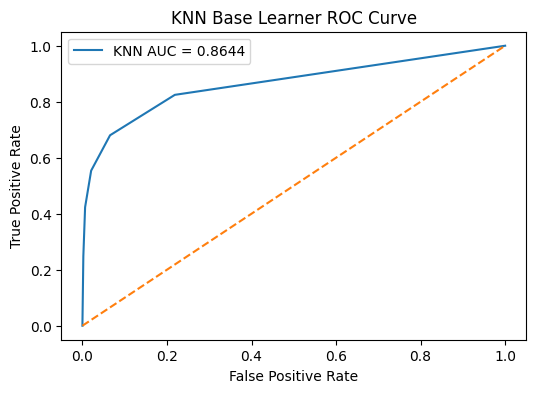

In [ ]:
# Compute and plot the ROC curve for KNN.
knn_base_fpr, knn_base_tpr, _ = roc_curve(y_cls_test, knn_base_prob)
knn_base_auc = roc_auc_score(y_cls_test, knn_base_prob)

plt.figure(figsize=(6, 4))
plt.plot(knn_base_fpr, knn_base_tpr, label=f"KNN AUC = {knn_base_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN Base Learner ROC Curve")
plt.legend()
plt.show()

### Build the soft voting ensemble classifier
The ensemble combines the probabilities from the two base learners.

In [ ]:
# Declare the soft voting ensemble classifier using the two fitted base learner structures.
ensemble_model = VotingClassifier(
    estimators=[
        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ])),
        ("knn", Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]))
    ],
    voting="soft"
)

In [ ]:
# Fit the ensemble classifier on the classification training data.
ensemble_model.fit(X_cls_train, y_cls_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               LogisticRegression(max_iter=1000,
                                                                  random_state=42))])),
                             ('knn',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               KNeighborsClassifier())]))],
                 voting='soft')

In [ ]:
# Generate predictions from the ensemble classifier.
ensemble_pred = ensemble_model.predict(X_cls_test)

# Generate probability scores from the ensemble classifier.
ensemble_prob = ensemble_model.predict_proba(X_cls_test)[:, 1]

In [ ]:
# Display the confusion matrix for the ensemble classifier.
ensemble_cm = confusion_matrix(y_cls_test, ensemble_pred)
print("Voting Ensemble Confusion Matrix:")
print(ensemble_cm)

Voting Ensemble Confusion Matrix:
[[9910  149]
 [ 810  860]]


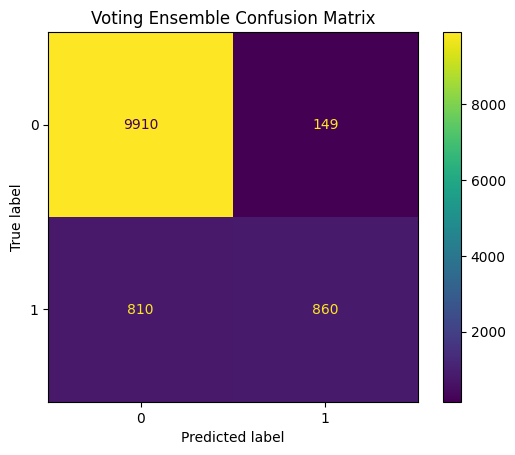

In [ ]:
# Plot the confusion matrix for the ensemble classifier.
disp = ConfusionMatrixDisplay(confusion_matrix=ensemble_cm)
disp.plot()
plt.title("Voting Ensemble Confusion Matrix")
plt.show()

In [ ]:
# Display the classification report for the ensemble classifier.
print("Voting Ensemble Classification Report:")
print(classification_report(y_cls_test, ensemble_pred))

Voting Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10059
           1       0.85      0.51      0.64      1670

    accuracy                           0.92     11729
   macro avg       0.89      0.75      0.80     11729
weighted avg       0.91      0.92      0.91     11729



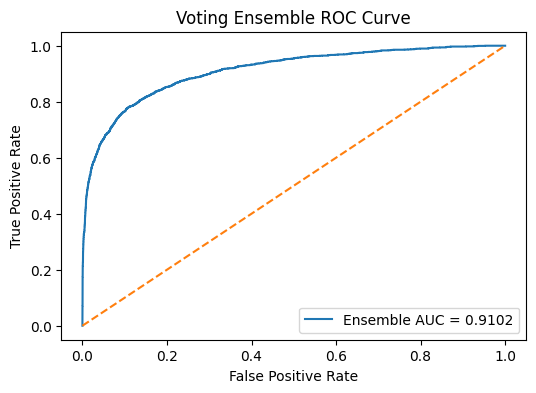

In [ ]:
# Compute and plot the ROC curve for the ensemble classifier.
ensemble_fpr, ensemble_tpr, _ = roc_curve(y_cls_test, ensemble_prob)
ensemble_auc = roc_auc_score(y_cls_test, ensemble_prob)

plt.figure(figsize=(6, 4))
plt.plot(ensemble_fpr, ensemble_tpr, label=f"Ensemble AUC = {ensemble_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Voting Ensemble ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Create a comparison table for the two base learners and the ensemble classifier.
ensemble_results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Voting Ensemble"],
    "AUC": [lr_base_auc, knn_base_auc, ensemble_auc]
})

# Display the comparison table.
ensemble_results_df

,Model,AUC
0,Logistic Regression,0.888318
1,KNN,0.864379
2,Voting Ensemble,0.910207


## Part B: Regression Decision Trees for Maximum Loan Amount
This section builds:
- DT-1: Fully grown Decision Tree Regressor
- DT-2: Pruned Decision Tree Regressor with max_depth = 4

In [ ]:
regression_df.columns.tolist()

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'max_allowed_loan',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

In [ ]:
print(regression_df["max_allowed_loan"].describe())
print(regression_df["max_allowed_loan"].head())

count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
0   -2426900
1    -111739
2     -89000
3      35000
4      35000
Name: max_allowed_loan, dtype: int64


In [ ]:
# Separate the regression features and target variable.
X_reg = regression_df.drop("max_allowed_loan", axis=1)
y_reg = regression_df["max_allowed_loan"]

# Display the regression feature names.
X_reg.columns.tolist()

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

In [ ]:
# Display the regression feature matrix and target vector shapes.
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

X_reg shape: (50295, 16)
y_reg shape: (50295,)


In [ ]:
# Split the regression data into training and testing sets.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Display the regression split shapes.
print("X_reg_train shape:", X_reg_train.shape)
print("X_reg_test shape:", X_reg_test.shape)
print("y_reg_train shape:", y_reg_train.shape)
print("y_reg_test shape:", y_reg_test.shape)

X_reg_train shape: (40236, 16)
X_reg_test shape: (10059, 16)
y_reg_train shape: (40236,)
y_reg_test shape: (10059,)


### Build DT-1: Fully grown regression tree

In [ ]:
# Declare the fully grown Decision Tree Regressor.
dt1_model = DecisionTreeRegressor(random_state=42)

# Fit the fully grown Decision Tree Regressor.
dt1_model.fit(X_reg_train, y_reg_train)

DecisionTreeRegressor(random_state=42)

### Build DT-2: Pruned regression tree with maximum depth 4

In [ ]:
# Declare the pruned Decision Tree Regressor with a depth limit of 4.
dt2_model = DecisionTreeRegressor(max_depth=4, random_state=42)

# Fit the pruned Decision Tree Regressor.
dt2_model.fit(X_reg_train, y_reg_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
# Generate predictions from DT-1 on the regression test data.
dt1_pred = dt1_model.predict(X_reg_test)

# Generate predictions from DT-2 on the regression test data.
dt2_pred = dt2_model.predict(X_reg_test)

### Evaluate DT-1 and DT-2 using MSE, MAE, and R-squared

In [ ]:
# Calculate the regression metrics for DT-1.
dt1_mse = mean_squared_error(y_reg_test, dt1_pred)
dt1_mae = mean_absolute_error(y_reg_test, dt1_pred)
dt1_r2 = r2_score(y_reg_test, dt1_pred)

# Print the regression metrics for DT-1.
print("DT-1 Fully Grown Regression Metrics")
print("MSE:", dt1_mse)
print("MAE:", dt1_mae)
print("R-squared:", dt1_r2)

DT-1 Fully Grown Regression Metrics
MSE: 60118061.8641018
MAE: 1239.1713888060444
R-squared: 0.9797826691747992


In [ ]:
# Calculate the regression metrics for DT-2.
dt2_mse = mean_squared_error(y_reg_test, dt2_pred)
dt2_mae = mean_absolute_error(y_reg_test, dt2_pred)
dt2_r2 = r2_score(y_reg_test, dt2_pred)

# Print the regression metrics for DT-2.
print("DT-2 Pruned Regression Metrics")
print("MSE:", dt2_mse)
print("MAE:", dt2_mae)
print("R-squared:", dt2_r2)

DT-2 Pruned Regression Metrics
MSE: 404642149.1825342
MAE: 11935.257767292323
R-squared: 0.8639213583708603


In [ ]:
# Create a regression model comparison table.
regression_results_df = pd.DataFrame({
    "Model": ["DT-1 Fully Grown", "DT-2 Pruned"],
    "MSE": [dt1_mse, dt2_mse],
    "MAE": [dt1_mae, dt2_mae],
    "R-squared": [dt1_r2, dt2_r2]
})

# Display the regression comparison table.
regression_results_df

,Model,MSE,MAE,R-squared
0,DT-1 Fully Grown,6.011806e+07,1239.171389,0.979783
1,DT-2 Pruned,4.046421e+08,11935.257767,0.863921


### Visualise DT-1

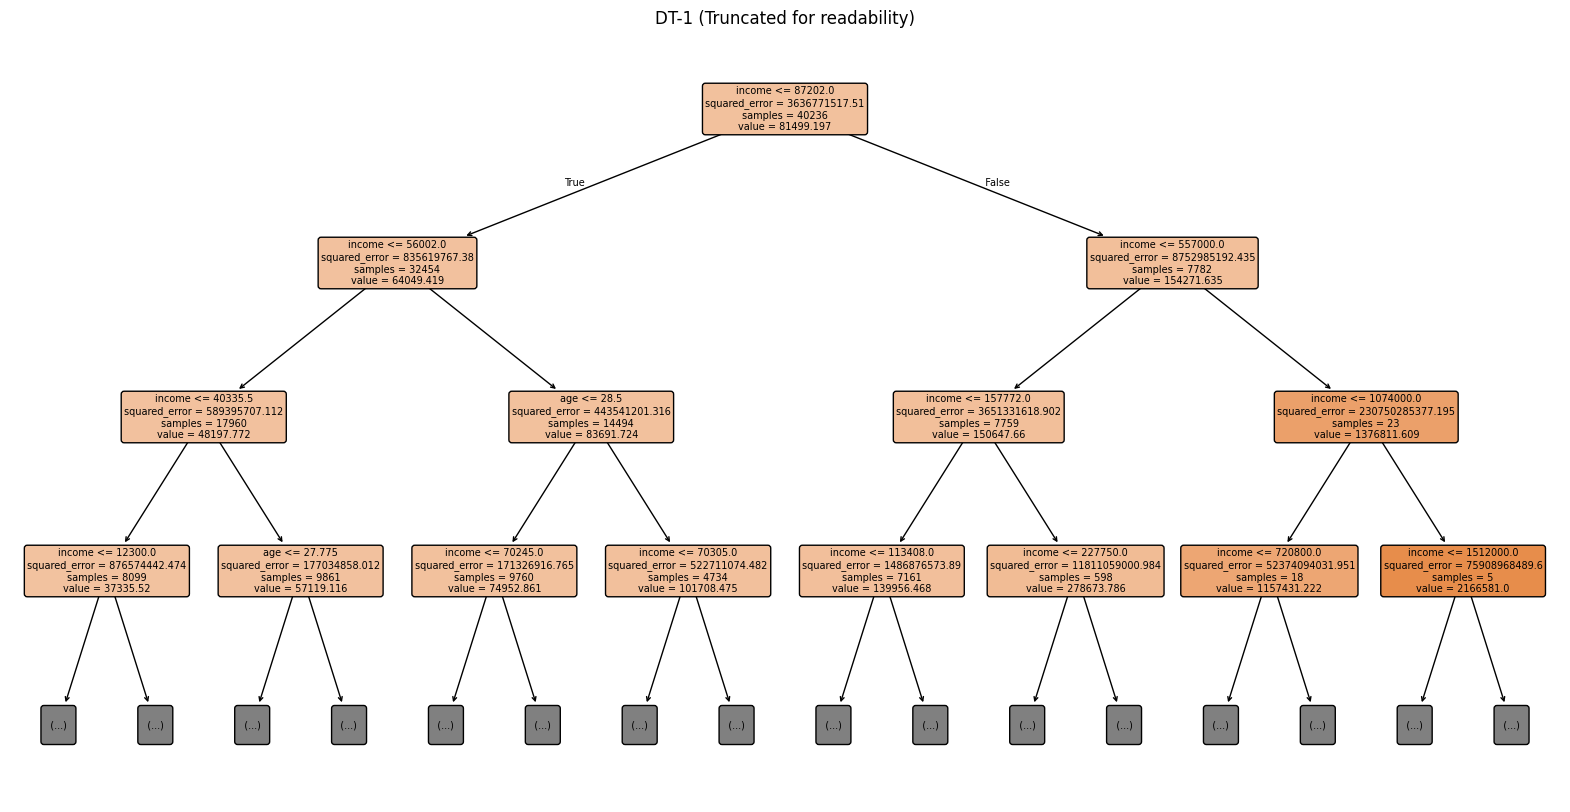

In [ ]:
# Plot the fully grown Decision Tree Regressor.
plt.figure(figsize=(20,10))
plot_tree(
    dt1_model,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3  # Truncate the tree for readability
)
plt.title("DT-1 (Truncated for readability)")
plt.show()

### Visualise DT-2

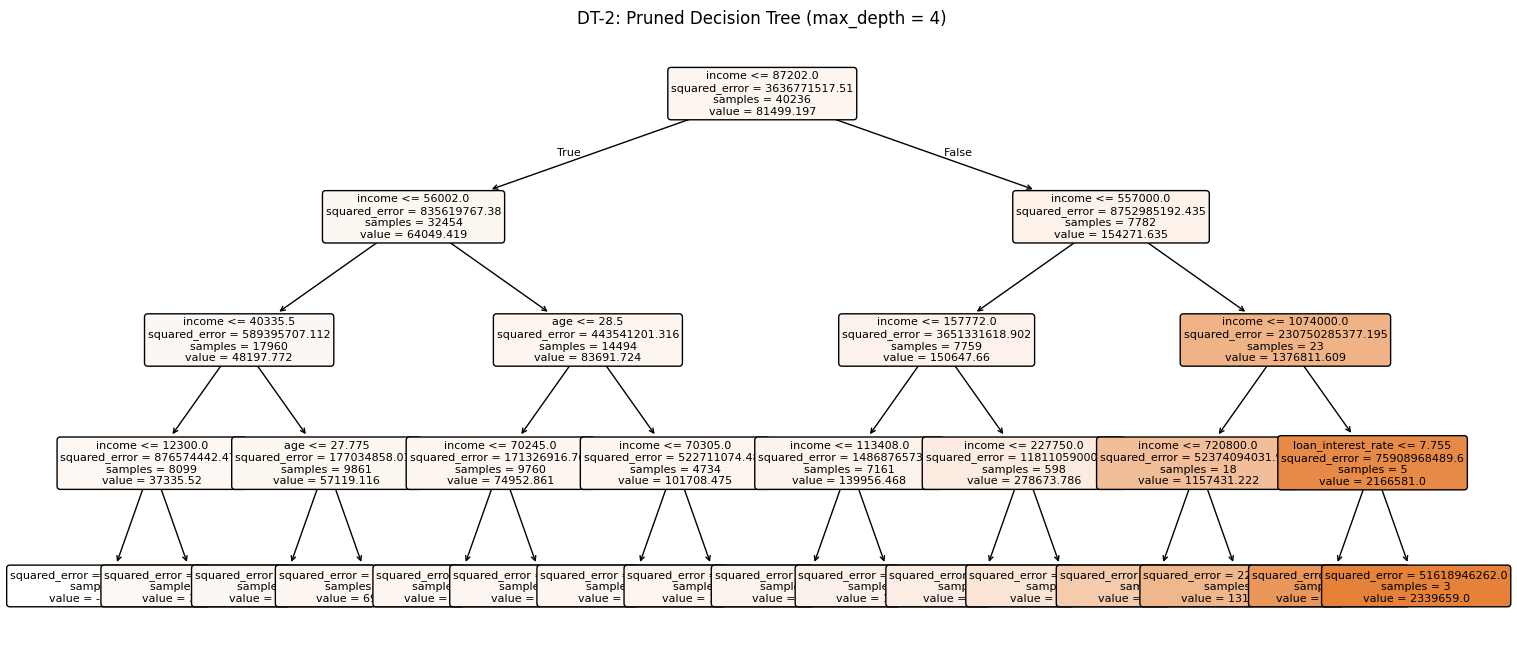

In [ ]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt2_model,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("DT-2: Pruned Decision Tree (max_depth = 4)")
plt.show()

### Predict the maximum loan amount for Client 60256
This section uses the selected best regression model to estimate the offer for the provided client.

In [ ]:
# Display the regression feature names again to ensure correct client input construction.
X_reg.columns.tolist()

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

### Important
Before running the next cell, make sure the dictionary keys exactly match the feature names shown above.
Because your regression dataset was one-hot encoded in Notebook 1, the client input must use the same encoded feature names.

In [ ]:
# Create a blank dictionary for all regression input features with default value 0.
client_60256 = {col: 0 for col in X_reg.columns}

In [ ]:
# Fill the numeric feature values for Client 60256.
if "age" in client_60256:
    client_60256["age"] = 56

if "income" in client_60256:
    client_60256["income"] = 57000

if "employment_length" in client_60256:
    client_60256["employment_length"] = 15

if "loan_amount" in client_60256:
    client_60256["loan_amount"] = 25700

if "loan_interest_rate" in client_60256:
    client_60256["loan_interest_rate"] = 23

if "loan_income_ratio" in client_60256:
    client_60256["loan_income_ratio"] = 10

if "credit_history_length" in client_60256:
    client_60256["credit_history_length"] = 35

if "loan_approval_status" in client_60256:
    client_60256["loan_approval_status"] = 1

In [ ]:
# Activate the correct one-hot encoded categorical values for Client 60256 where those columns exist.
for col in X_reg.columns:
    if col == "sex_M":
        client_60256[col] = 0
    if col == "home_ownership_RENT":
        client_60256[col] = 1
    if col == "loan_intent_MEDICAL":
        client_60256[col] = 1
    if col == "payment_default_on_file_Y":
        client_60256[col] = 0
    if col == "education_qualifications_Unknown":
        client_60256[col] = 1

In [ ]:
# Convert the client dictionary into a one-row DataFrame using the same feature order as the training data.
client_60256_df = pd.DataFrame([client_60256])[X_reg.columns]

# Display the prepared client row.
client_60256_df

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,56,57000,0,25700,23,10,35,0,0,1,0,0,1,0,0,0


In [ ]:
# Select the better regression model based on lower MAE as a practical criterion.
if dt1_mae <= dt2_mae:
    best_regression_model = dt1_model
    best_regression_model_name = "DT-1 Fully Grown"
else:
    best_regression_model = dt2_model
    best_regression_model_name = "DT-2 Pruned"

# Print the selected best regression model.
print("Selected best regression model:", best_regression_model_name)

Selected best regression model: DT-1 Fully Grown


In [ ]:
# Predict the maximum loan amount for Client 60256 using the selected best regression model.
client_60256_prediction = best_regression_model.predict(client_60256_df)[0]

# Display the predicted maximum loan amount.
print("Predicted Maximum Loan Amount for Client 60256:", client_60256_prediction)

Predicted Maximum Loan Amount for Client 60256: 83035.0


### Final summary
This notebook completed:
- A soft voting ensemble classifier using Logistic Regression and KNN
- Base learner evaluation and ensemble evaluation
- DT-1 fully grown regression tree
- DT-2 pruned regression tree
- Decision tree visualisation
- Regression metrics comparison
- Client 60256 maximum loan amount prediction